## Selective Subsampling (SS)

In [ ]:
from utils import seeded_input_random
import numpy as np

def selective_subsampling(stream, order, r1=10, r2=30, q=1/100):
    '''
    Description:
        Uses selective subsampling algorithm to estimate order norm of frequency vector
    Inputs:
        stream: stream of random values
        order: order of norm
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold for ss algorithm
    Outputs:
        returns estimated order norm of frequency vector
    '''
    t = [[{} for _ in range(r2)] for _ in range(r1)]
    for s_i in stream:
        for i in range(r1):
            t_i = t[i]
            for j in range(r2):
                curr_t = t_i[j]
                prob = seeded_input_random(i*j + s_i, s_i)
                if (prob < q):
                    curr_t.setdefault(s_i, 0)
                    curr_t[s_i] += 1
    r1_norms = []
    for i in range(r1):
        r2_norms = []
        t_i = t[i]
        for j in range(r2):
            curr_t = t_i[j]
            moment = np.sum(np.power(list(curr_t.values()), order))
            r2_norms.append(
                    np.power((1/q * moment), 1/order)
                )
        r1_norms.append(np.mean(r2_norms))
    return np.median(r1_norms)
              

### Uniform Stream Test 

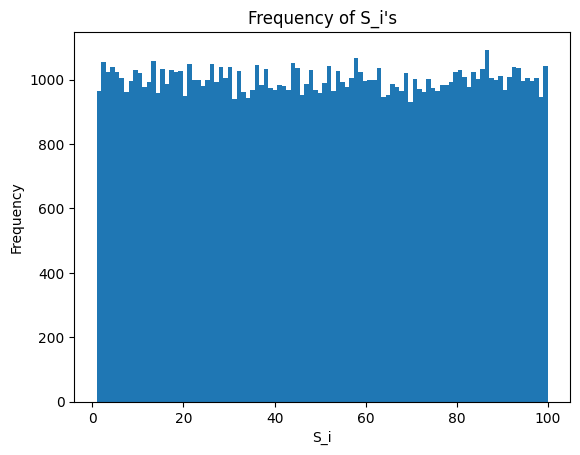

In [93]:
from utils import generate_stream_uniform, plot_stream

m_uniform=int(1e5)
n_uniform=100

stream_unif, freq_unif = generate_stream_uniform(n_uniform, m_uniform)
plot_stream(stream_unif, n_uniform)

### Skewed Stream Test 

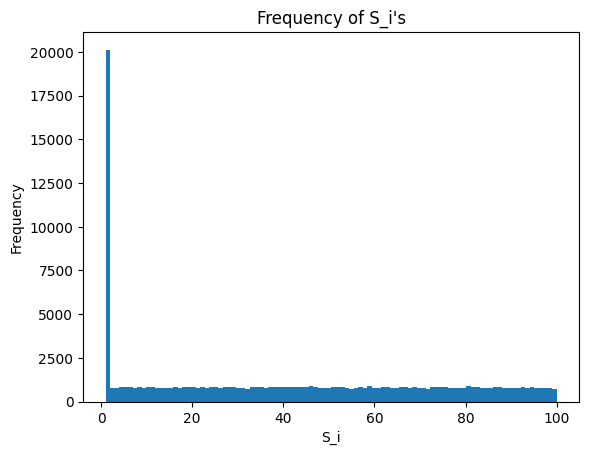

SS Result: 3145.0766038846696
Ground Truth: 20174.83259541451


In [88]:
from utils import generate_stream_skewed, plot_stream

m_skewed = int(1e5)
n_skewed = 100

stream_skewed, freq_skewed = generate_stream_skewed(n_skewed, m_skewed)
plot_stream(stream_skewed, n_skewed)

print("SS Result:", selective_subsampling(stream_skewed, 3))
print("Ground Truth:", np.linalg.norm(freq_skewed, 3))

## Selective Subsampling Augmented (SSA)

In [22]:
def estimate_norm(timestep, order, r1, r2, q):
    '''
    Description:
        Helper function to estimate norm at timestep based on its histogram
    Input:
        hist: histogram to use for norms
        timestep: timestep for which to estimte order norm
        order: order of norm
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold of ssa algorithm
    Returns:
        Order norm at timestep
    '''
    t = hist_ssa[timestep] # keeps track of samples
    r1_norms = []
    for i in range(r1):
        r2_norms = []
        t_i = t[i] # sample for current iteration
        for j in range(r2):
            curr_t = t_i[j]
            moment = np.sum(np.power(list(curr_t.values()), order))
            r2_norms.append(
                    np.power((1/q * moment), 1/order)
                )
        r1_norms.append(np.mean(r2_norms))
    rest_est = np.median(r1_norms)
    temp_arr = np.concatenate((hist_hh_sums[timestep], [rest_est]))
    return np.linalg.norm(temp_arr, order)

In [23]:

def prune_threads_ssa(order, r1, r2, q):
    '''
    Description:
        Removes adjacent threads that are within a threshold of 2
    Inputs:
        order: order of norm
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold for ssa algorithm
    '''
    i = 0 # index variable
    while (i < len(threads_vec_ssa)):
        # boundary check
        if (i >= len(threads_vec_ssa) - 2):
            return
        t_i = threads_vec_ssa[i] # thread identity
        ssa_ti = estimate_norm(t_i, order, r1, r2, q) # ssa estimate for thread

        t_i2 = threads_vec_ssa[i+2] # adjcaent thread
        ssa_ti2 = estimate_norm(t_i2, order, r1, r2, q) # ssa estimate for adjancent thread
        
        # check distance, prune hist, threads
        denom = min(ssa_ti, ssa_ti2)
        if (denom != 0 and (max(ssa_ti, ssa_ti2)/denom <= 2)):
            # remove the thread in between
            t_i1 = threads_vec_ssa[i+1]
            threads_vec_ssa.pop(i+1)
            hist_ssa.pop(t_i1)
            hist_ss.pop(t_i1)
            hist_hh_sums.pop(t_i1)
            i -= 1
        i += 1

In [24]:
def spawn_threads_ssa(timestep, order, l, r1, r2, q):
    '''
    Description:
        Helper function to spawn threads for ssa
    Inputs:
        timestep: timestep identifier to spawn threads for ssa
        order: order of norm
        l: number of heavy hitters
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold for ssa algorithm
    '''
    if (len(threads_vec_ssa) == num_threads_max):
        prune_threads_ssa(order, r1, r2, q)
    if (len(threads_vec_ssa) < num_threads_max):
        threads_vec_ssa.append(timestep)
        hist_ssa[timestep] = [[{} for _ in range(r2)] for _ in range(r1)]
        hist_ss[timestep] = [[{} for _ in range(r2)] for _ in range(r1)]
        hist_hh_sums[timestep] = np.zeros(l)
        
    

In [28]:
import numpy as np
from utils import seeded_input_random

def selective_subsampling_augmented(heavy, stream, order, r1, r2, q, q_ss):
    '''
    Description:
        Uses augmented selective subsampling algorithm to estimate order norm of frequencies
    Inputs:
        heavy: list of heavy hitters
        stream: stream vector of random values
        order: order of norm
        r1: number of values to take median of
        r2: number of values to take mean of
        q: threshold for ssa algorithm
        q_ss: threshold for ss algorithm
    Outputs:
        returns estimated order norm of frequency vector
    '''
    time = 0
    for s_i in stream:
        # run augmented algorithm
        spawn_threads_ssa(time, order, len(heavy), r1, r2, q)
        try:
            index = heavy.index(s_i)
            # s_i is a heavy hitter
            for thread in threads_vec_ssa:
                t = hist_hh_sums[thread]
                t[index] += 1
        except ValueError:
            # s_i is not a heavy hitter
            for thread in threads_vec_ssa:
                t = hist_ssa[thread]
                for i in range(r1):
                    t_i = t[i]
                    for j in range(r2):
                        curr_t = t_i[j]
                        prob = seeded_input_random((i+1)*(j+1) + s_i, s_i)
                        if (prob < q):
                            curr_t.setdefault(s_i, 0)
                            curr_t[s_i] += 1
        finally:
             # run ss in parallel
            for thread in threads_vec_ssa:
                t = hist_ss[thread]
                for i in range(r1):
                    t_i = t[i]
                    for j in range(r2):
                        curr_t = t_i[j]
                        prob = seeded_input_random((i+1)*(j+1) + s_i, s_i)
                        if (prob < q_ss):
                            curr_t.setdefault(s_i, 0)
                            curr_t[s_i] += 1
            time += 1


### Uniform Stream Test

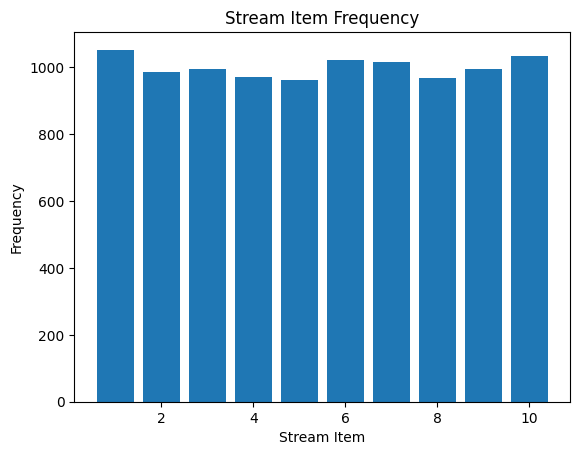

In [ ]:
from utils import generate_stream_uniform, plot_stream

m_uniform=int(1e4)
n_uniform=10

stream_unif, freq_unif = generate_stream_uniform(n_uniform, m_uniform)
plot_stream(stream_unif)

#setup shared variables
hh = []
hist_ssa = {} # maps timestep to ssa value
hist_ss = {} # maps timestep to ss value
hist_hh_sums = {} # maps timestep to hh sum value
threads_vec_ssa = [] # stores thread identities
num_threads_max = 20 # hyperparam for max counters
order = 3 # norm order
r1 = 3 # number of values to take mean of
r2 = 5 # number of values to take median of
q = 1/100 # ssa sample selection probability
q_ss = 1/10 # ss sample selection probability

selective_subsampling_augmented(heavy=hh, stream=stream_unif, order=order, r1=r1, r2=r2, q=q, q_ss=q_ss)


#### Visualize Results

In [12]:
def norm_helper(time, order, r1, r2, q):
    '''
        Description:
            Helper function to calculate order norm for ss
        Inputs:
            time: timestep for calculation
            order: order of norm
            r1: number of values to take median of
            r2: number of values to take mean of
            q: threshold for ss algorithm
        Outputs:
            order norm
    '''
    t = hist_ss[time] # keeps track of samples
    r1_norms = []
    for i in range(r1):
        r2_norms = []
        t_i = t[i] # sample for current iteration
        for j in range(r2):
            curr_t = t_i[j]
            moment = np.sum(np.power(list(curr_t.values()), order))
            r2_norms.append(
                    np.power((1/q * moment), 1/order)
                )
        r1_norms.append(np.mean(r2_norms))
    
    return np.median(r1_norms)

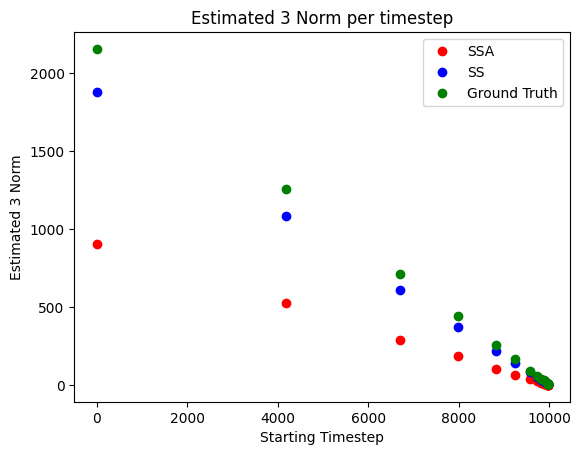

In [13]:
import matplotlib.pyplot as plt

# calculate estimates
timesteps = []
est_ssa = []
est_ss = []
gt = []

for time in hist_ssa.keys():
    timesteps.append(time)
    est_ssa.append(estimate_norm(time, order, r1, r2, q))
    est_ss.append(norm_helper(time, order, r1, r2, q_ss))
    _, temp_freq = np.unique(stream_unif[time:], return_counts=True)
    gt.append(np.linalg.norm(temp_freq, 3))

# plot estimates
_, ax = plt.subplots()

ax.plot(timesteps, est_ssa, 'ro', label="SSA")
ax.plot(timesteps, est_ss, 'bo', label="SS")
ax.plot(timesteps, gt, 'go', label="Ground Truth")
ax.set_title("Estimated 3 Norm per timestep")
ax.set_xlabel("Starting Timestep")
ax.set_ylabel("Estimated 3 Norm")
ax.legend()
plt.show()


### Skewed Stream Test 

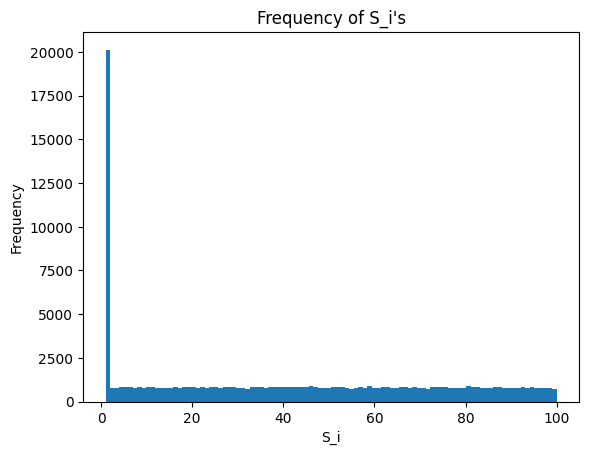

In [22]:
from utils import generate_stream_skewed, plot_stream

m_skewed=int(1e5)
n_skewed=100

#setup shared variables
hh = [1]
hist_ssa = {} # maps timestep to ssa value
hist_ss = {} # maps timestep to ss value
hist_hh_sums = {} # maps timestep to hh sum value
threads_vec_ssa = [] # stores thread identities
num_threads_max = 20 # hyperparam for max counters

stream_skewed, freq_skewed = generate_stream_skewed(n_skewed, m_skewed)
plot_stream(stream_skewed, n_skewed)

selective_subsampling_augmented(hh, stream_skewed, 3)


#### Visualize Results

/var/folders/vm/qg92d4j56_l5x0q4g9hbq4j80000gn/T/ipykernel_50974/2776345222.py:33: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = lambda x, y: max(x, y)/min(x, y)


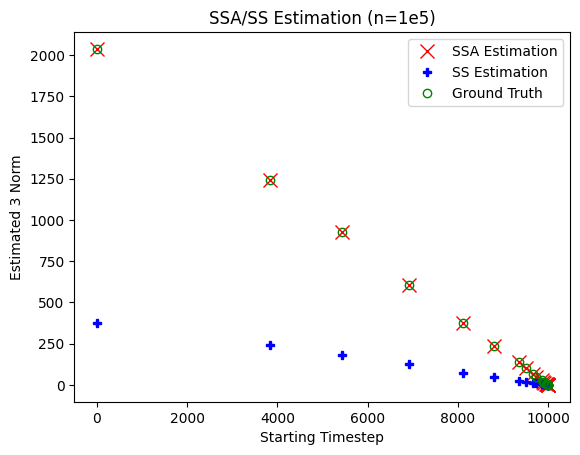

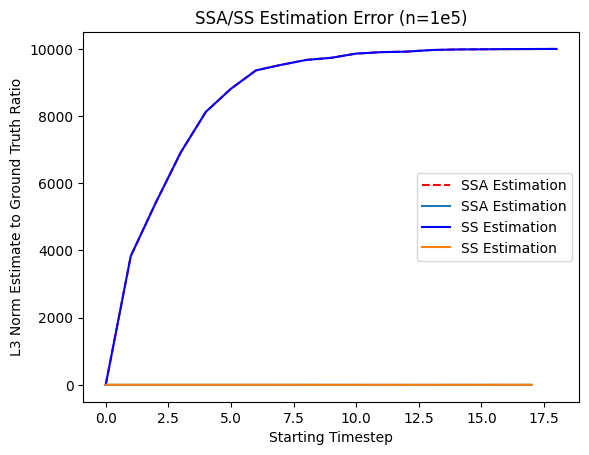

In [ ]:
import matplotlib.pyplot as plt

timesteps = []
est_ssa = []
est_ss = []
gt = []
r1 = 3
r2 = 5
order = 3
q = 1/100
q_ss = 1/10

for time in hist_ssa.keys():
    timesteps.append(time)
    est_ssa.append(estimate_norm(time, order, r1, r2, q))
    est_ss.append(norm_helper(time, order, r1, r2, q_ss))    
    _, temp_freq = np.unique(stream_skewed[time:], return_counts=True)
    gt.append(np.linalg.norm(temp_freq, order))

# plot the values
_, ax = plt.subplots()

ax.plot(timesteps, est_ssa, 'rx', label="SSA Estimation", markersize=10)
ax.plot(timesteps, est_ss, 'bP', label="SS Estimation")
ax.plot(timesteps, gt, 'go', label="Ground Truth", fillstyle='none')
ax.set_title(f"SSA/SS Estimation (n={m:.1e})")
ax.set_xlabel("Starting Timestep")
ax.set_ylabel("Estimated 3 Norm")
ax.legend()


# plot the ratio
ratio = lambda x, y: max(x, y)/min(x, y)
err_ss = np.array(list(map(ratio, est_ss, gt)))
err_ssa = np.array(list(map(ratio, est_ssa, gt)))

_, ax2 = plt.subplots()
ax2.plot(timesteps[:-1], err_ssa[:-1],'r--', label="SSA Estimation")
ax2.plot(timesteps[:-1], err_ss[:-1], 'b-', label="SS Estimation")
ax2.set_xlabel("Starting Timestep")
ax2.set_ylabel(f"L3 Norm Estimate to Ground Truth Ratio")
ax2.set_title(f"SSA/SS Estimation Error (n={m:.1e})")
ax2.legend()
plt.show()

### Shift Stream Test 

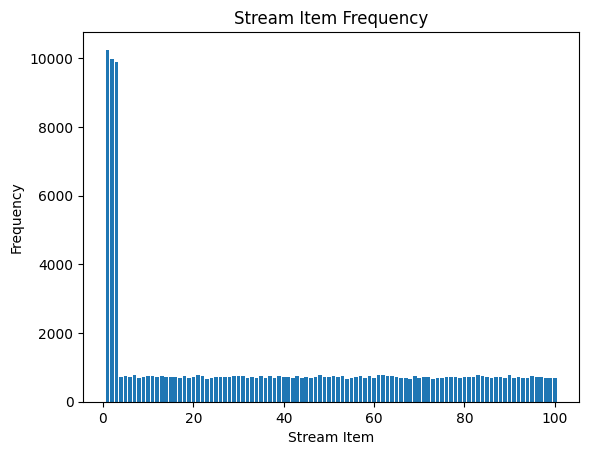

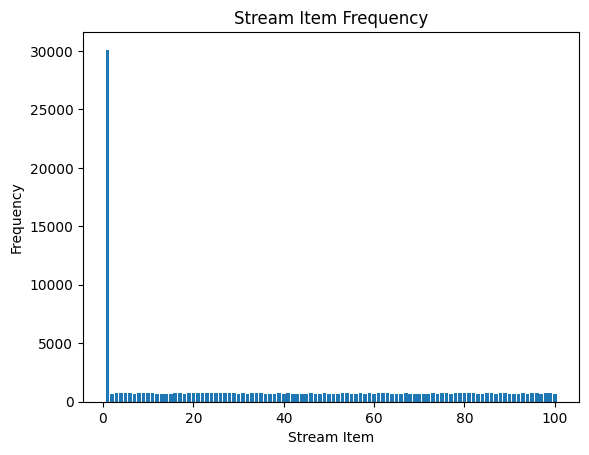

In [80]:
from utils import generate_stream_skewed, plot_stream

m=int(1e5)
n=100
q1, k1 = (3, 1)
q2, k2 = (1, 3)

skwd_s1, skwd_f1 = generate_stream_skewed(n=n, m=m, q=q1, k=k1)
skwd_s2, skwd_f2 = generate_stream_skewed(n=n, m=m, q=q2, k=k2)

plot_stream(skwd_s1)
plot_stream(skwd_s2)


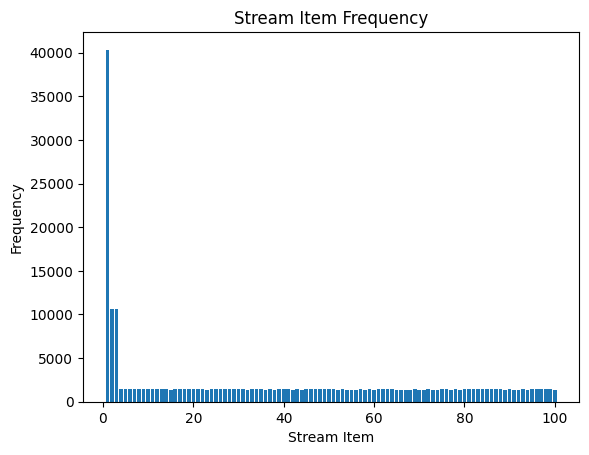

In [81]:
# concatenate the streams

shftd_stream = np.concatenate((skwd_s1, skwd_s2))
shftd_freq = np.add(skwd_f1, skwd_f2)
m*=2

plot_stream(shftd_stream)

In [82]:
# setup shared variables
hh = [1, 2, 3]
hist_ssa = {} # maps timestep to ssa value
hist_ss = {} # maps timestep to ss value
hist_hh_sums = {} # maps timestep to hh sum value
threads_vec_ssa = [] # stores thread identities
num_threads_max = 20 # hyperparam for max counters
order = 3 # norm order
r1 = 3 # number of values to take mean of
r2 = 5 # number of values to take median of
q = 1/100 # sample selection probability ssa
q_ss = 1/10 # sample selection probabioity ss

selective_subsampling_augmented(heavy=hh, stream=shftd_stream, order=order, r1=r1, r2=r2, q=q, q_ss=q_ss)


#### Visualize Results 

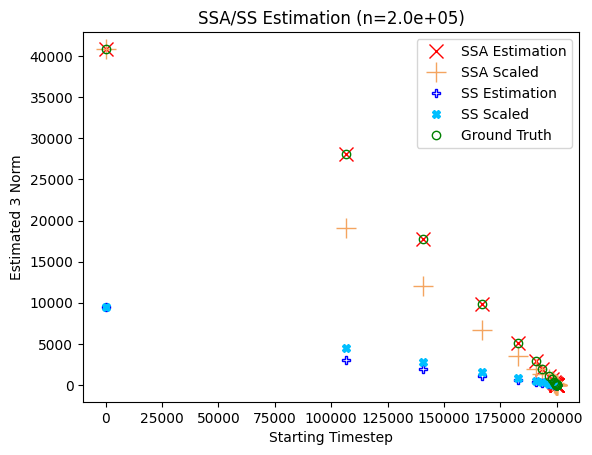

In [99]:
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
from matplotlib.transforms import Affine2D


timesteps = []
est_ssa = []
est_ss = []
gt = []

# compute estimates
for time in hist_ssa.keys():
    timesteps.append(time)
    est_ssa.append(estimate_norm(time, order, r1, r2, q))
    est_ss.append(norm_helper(time, order, r1, r2, q_ss))    
    _, temp_freq = np.unique(shftd_stream[time:], return_counts=True)
    gt.append(np.linalg.norm(temp_freq, order))

ssa_scaled = [est_ssa[0] * (m-t_i)/m for t_i in timesteps]
ss_scaled = [est_ss[0] * (m-t_i)/m for t_i in timesteps]


# plot the values
_, ax = plt.subplots()

ax.plot(timesteps, est_ssa, 'rx', label="SSA Estimation", markersize=10)
rotate = Affine2D().rotate_deg(45)
rot_x = MarkerStyle('x', transform=rotate)
ax.plot(timesteps, ssa_scaled, marker=rot_x, label="SSA Scaled", linestyle='None', markersize=10, color="sandybrown")

ax.plot(timesteps, est_ss, 'bP', label="SS Estimation", fillstyle='none')
rot_plus = MarkerStyle('P', transform=rotate)
ax.plot(timesteps, ss_scaled, marker=rot_plus, label="SS Scaled", linestyle='None', color="deepskyblue")

ax.plot(timesteps, gt, 'go', label="Ground Truth", fillstyle='none')

ax.set_title(f"SSA/SS Estimation (n={m:.1e})")
ax.set_xlabel("Starting Timestep")
ax.set_ylabel("Estimated 3 Norm")
ax.legend()

plt.show()

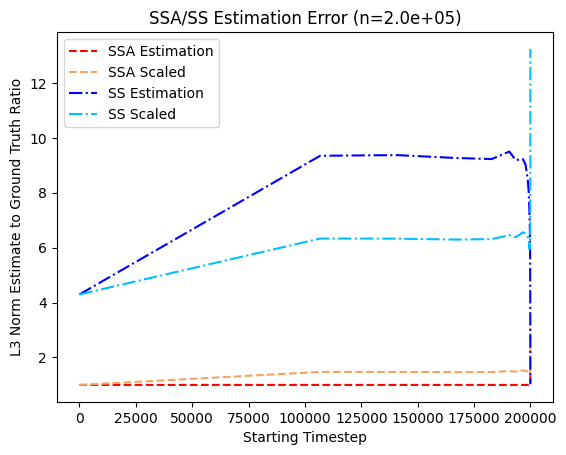

In [103]:
# plot the ratio
ratio = lambda x, y: max(x, y)/min(x, y)
err_ss = np.array(list(map(ratio, est_ss, gt)))
err_ssa = np.array(list(map(ratio, est_ssa, gt)))
err_ss_scaled = np.array(list(map(ratio, ss_scaled, gt)))
err_ssa_scaled = np.array(list(map(ratio, ssa_scaled, gt)))


_, ax2 = plt.subplots()
ax2.plot(timesteps, err_ssa, 'r--', label="SSA Estimation")
ax2.plot(timesteps, err_ssa_scaled, '--', label="SSA Scaled", color="sandybrown")
ax2.plot(timesteps, err_ss, 'b-.', label="SS Estimation")
ax2.plot(timesteps, err_ss_scaled, '-.', label="SS Scaled", color="deepskyblue")
ax2.set_xlabel("Starting Timestep")
ax2.set_ylabel(f"L3 Norm Estimate to Ground Truth Ratio")
ax2.set_title(f"SSA/SS Estimation Error (n={m:.1e})")
ax2.legend()
plt.show()